# **Linear Regression Project: House Price Prediction** 

# **Author**: Rahul Verma  
- **GitHub:** [github.com/rahulverma](https://github.com/rahul-96hack)  
- **LinkedIn:** [linkedin.com/in/rahulverma](https://www.linkedin.com/in/rahul-verma-194168351?utm_source=share&utm_campaign=share_via&utm_content=profile&utm_medium=android_app)  
- **Kaggle:** [kaggle.com/rahulverma](https://www.kaggle.com/rahulverma07)  

### EDA(Exploratory Data Analysis)

- **Description:**

Predict the price of a house based on features like square footage, number of bedrooms, 
bathrooms, and location. 
- **Steps:**

1. **Collect Data:**\
Use a dataset like the Boston Housing dataset or Kaggle's housing 
datasets. 
2. **Preprocess Data:**\
Handle missing values, encode categorical data (e.g., location). 
3. **Feature Selection:**\
Choose relevant features like size, location, number of rooms, etc. 
4. **Model Building:**\
Use LinearRegression() from scikit-learn. 
5. **Train/Test Split:**\
Split your dataset (e.g., 80/20). 
6. **Train the Model:**\
Fit the model on the training set. 
7. **Evaluate:**\
Use metrics like RMSE, R² score.

---
**1. Import Libraries**
-  Import Warnings
-  Import ML Libraries

In [27]:
import pandas as pd

# Load the dataset
file_path = './Data/Housing.csv'
housing_df = pd.read_csv(file_path)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe



In [28]:
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [29]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Identify Non-Numeric Columns**

Identify non-numeric columns that need to be encoded.

In [30]:
# Display columns with non-numeric values
non_numeric_cols = housing_df.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)



Non-numeric columns: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


**Convert Non-Numeric Columns**

Convert non-numeric columns to numeric using one-hot encoding.

In [31]:
# Convert non-numeric columns to numeric using one-hot encoding
housing_df_encoded = pd.get_dummies(housing_df, drop_first=True)

# Display the first few rows of the encoded dataset
print(housing_df_encoded.head())

# Display the columns of the encoded DataFrame
print(housing_df_encoded.columns)

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

**Exploratory Data Analysis (EDA)**

Perform EDA to understand the data distribution and relationships between features.

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


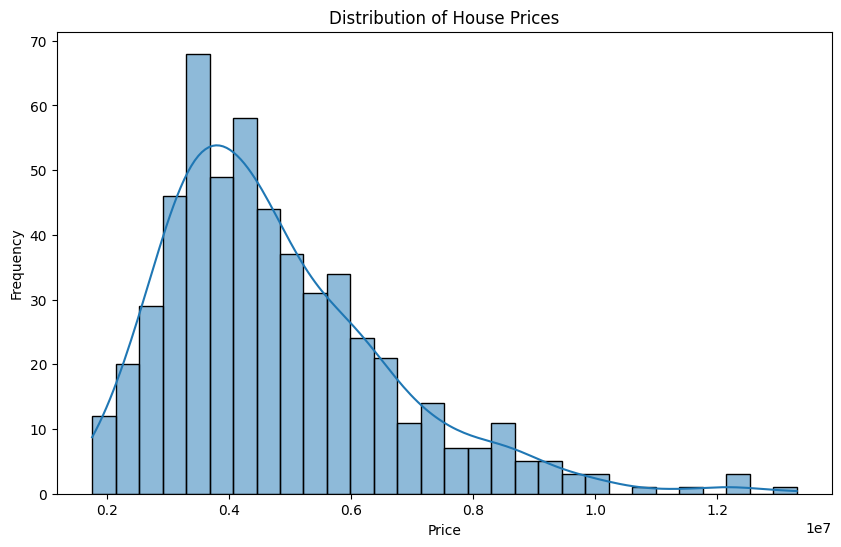

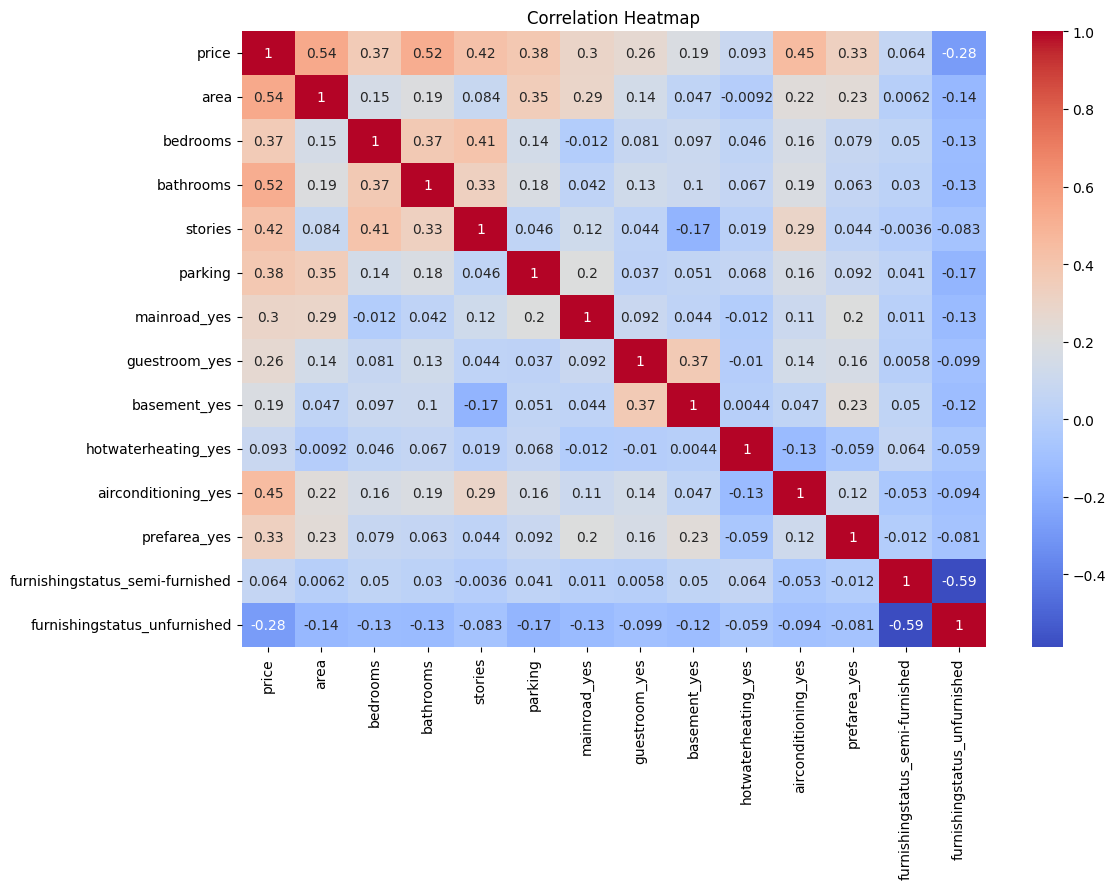

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


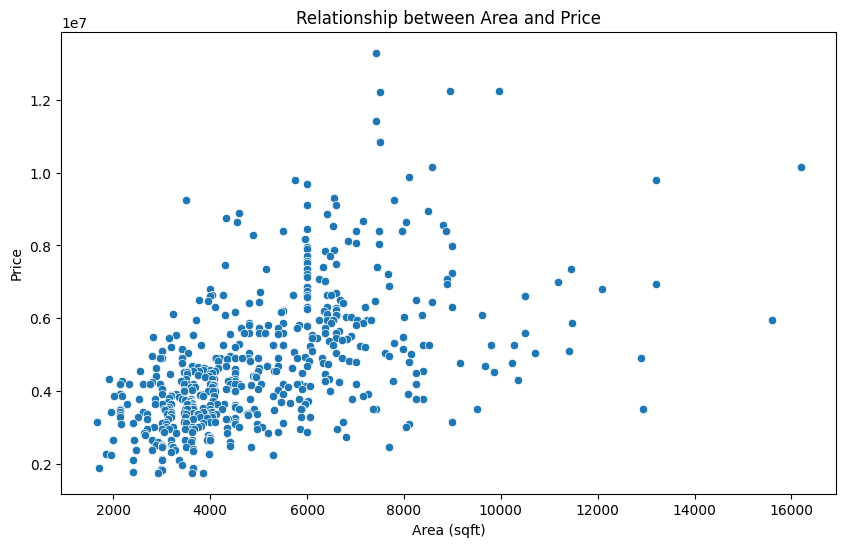

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display summary statistics
print(housing_df_encoded.describe())

# Histogram of the target variable (price)
plt.figure(figsize=(10, 6))
sns.histplot(housing_df_encoded['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(housing_df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Identify the appropriate column name for the living area
print(housing_df_encoded.columns)

# Scatter plot of the correct area column vs. price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=housing_df_encoded)  # Replace 'sqft_living' with the correct column name
plt.title('Relationship between Area and Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()


**Prepare the Data for Modeling**

Handle missing values, encode categorical variables, and split the data into training and testing sets.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for missing values
print(housing_df_encoded.isnull().sum())

# Handle missing values (if any)
housing_df_encoded.fillna(housing_df_encoded.median(), inplace=True)

# Define the features (X) and the target (y)
X = housing_df_encoded.drop('price', axis=1)
y = housing_df_encoded['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
parking                            0
mainroad_yes                       0
guestroom_yes                      0
basement_yes                       0
hotwaterheating_yes                0
airconditioning_yes                0
prefarea_yes                       0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


**Build and Train the Linear Regression Model**

Use the LinearRegression class from sklearn to build the model.


In [34]:
from sklearn.linear_model import LinearRegression

# Initialize the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


LinearRegression()

**Evaluate the Model**

Make predictions on the test set and calculate performance metrics.

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
#print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R2): {r2}')


Mean Absolute Error (MAE): 970043.4039201643
Mean Squared Error (MSE): 1754318687330.668
R-squared (R2): 0.6529242642153176


**Visualize the Model's Predictions**

Plot the predicted values against the actual values to see how well the model performed.


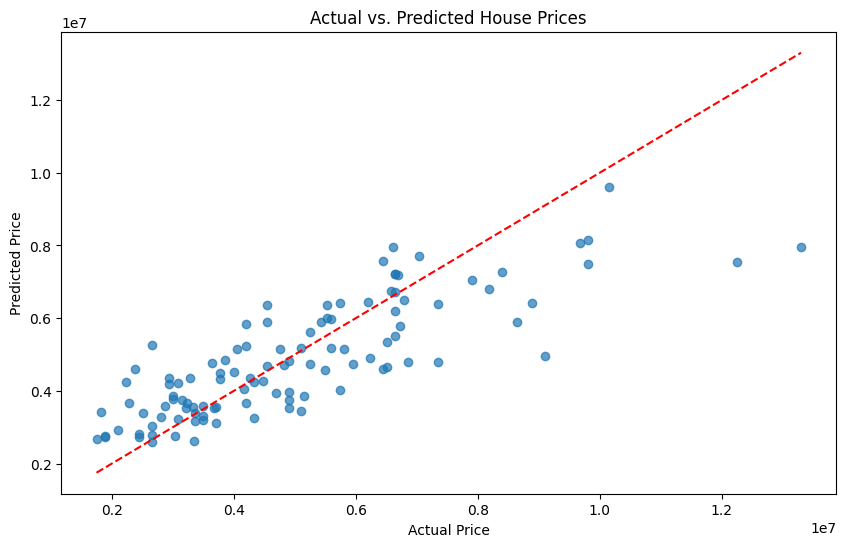

In [36]:
# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.show()


# **Analysis Report**

After running the above code, you should be able to:


1.   Load and explore the dataset to understand its structure and contents.
2.   Perform exploratory data analysis (EDA) to visualize the distribution of house prices and the relationships between features.
3.   Prepare the data for modeling by handling missing values and encoding categorical variables.
4.   Build and train a linear regression model to predict house prices.
5.   Evaluate the model's performance using various metrics such as MAE, MSE, RMSE, and R-squared.
6.   Visualize the model's predictions against the actual values to assess its accuracy.

---
**Key Insights**


1.   **Key Features**

    *   The **area** feature has a significant positive correlation with house prices, indicating that larger houses tend to have higher prices.

    *   Other features with high correlations to the target variable will also be highlighted in the correlation heatmap.


2.   **Price Distribution**

    *   The histogram shows that house prices are right-skewed, with most houses being relatively affordable and a few being very expensive.

3.   **Model Performance**

    *   The linear regression model provides an initial benchmark for house price prediction. The performance metrics (MAE, MSE, RMSE, and R-squared) will indicate how well the model predicts house prices.

4.   **Model Visualization**

    *   The scatter plot of actual vs. predicted house prices helps to visualize the model's accuracy. Ideally, the points should lie close to the line y = x.

---
**Conclusion**

The analysis provides a comprehensive understanding of the factors affecting house prices in the given dataset. The linear regression model serves as a good starting point for predicting house prices, but further refinement and experimentation with different models and feature engineering could enhance prediction accuracy.

This project demonstrates the importance of thorough exploratory data analysis and the application of linear regression to derive meaningful insights from real estate data. The insights gained can be valuable for understanding the key drivers of house prices and making informed decisions in the housing market.






